##  5-1 텐서플로에서 실행하는 단순 선형회귀

In [5]:
#######################################################
# [tf + keras] 단순선형회귀 : 공부시간 예제
#######################################################
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

x = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 

## 모델 생성
model = Sequential()

# 출력 값, 입력 변수, 분석 방법에 맞게끔 모델을 설정합니다. 
model.add(Dense(1, input_dim=1, activation='linear'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:

# 오차 수정을 위해 경사 하강법(sgd)을, 오차의 정도를 판단하기 위해 평균 제곱 오차(mse)를 사용합니다. 
model.compile(optimizer='sgd', loss='mse')  # default learning rate: 0.01
# model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')

# 오차를 최소화하는 과정을 2000번 반복합니다.
history = model.fit(x, y, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 918.8483
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 912.9523
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 907.0947
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 901.2751
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 895.4929
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 889.7484
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 884.0410
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 878.3706
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 872.7368
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 867.1395
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 861.5786
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 856.0537
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 850.5643
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 845.1108
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - 

In [ ]:
## 학습된 기울기(a)와 절편(b) 값 확인
model.get_weights()

[array([[4.741154]], dtype=float32), array([64.432236], dtype=float32)]

In [11]:
x, y

(array([2, 4, 6, 8]), array([81, 93, 91, 97]))

In [10]:
model.predict(x) # y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


array([[ 73.91454 ],
       [ 83.39685 ],
       [ 92.879166],
       [102.361465]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


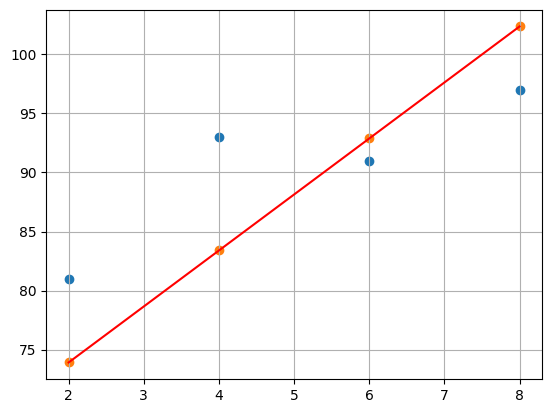

In [12]:
plt.scatter(x, y)
plt.scatter(x, model.predict(x))
plt.plot(x, model.predict(x),'r')    # 예측 결과를 그래프로 나타냅니다.
plt.grid()
plt.show()

In [ ]:
# 임의의 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.
hour = 7.0  # float로 넣어 주어야 함 (최근 버전)
prediction = model.predict(np.array([[hour]]))  # 반드시 2차원 array로 넣어 주어야 함

print("%.f시간을 공부할 경우의 예상 점수는 %.02f점입니다" % (hour, prediction[0][0]))

In [ ]:
hour, prediction

In [ ]:
model.get_weights()   # weight(a) 와 bias (b)

In [16]:
history_dict =history.history  # dictionary 형태로 반환됨
history_dict.keys()

dict_keys(['loss'])

In [19]:
len(history_dict['loss'])  # loss 값들만 확인 가능

500

In [20]:
import pandas as pd 
df_history = pd.DataFrame(history.history)
df_history

,loss
0,918.848267
1,912.952271
2,907.094727
3,901.275146
4,895.492920
...,...
495,44.843029
496,44.606403
497,44.371319
498,44.137756


<Axes: >

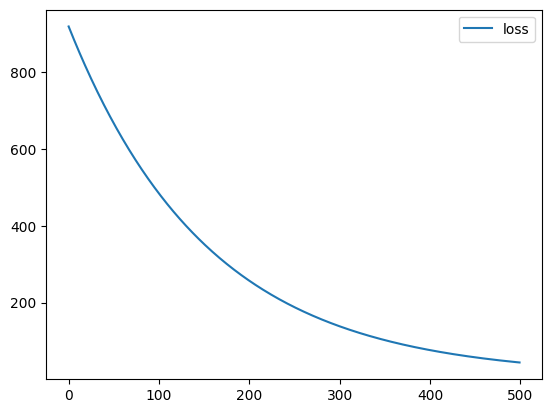

In [21]:
df_history.plot()

## 5-2 텐서플로에서 실행하는 다중 선형회귀 모델

In [25]:
#######################################################
# [tf + keras] 다중선형회귀 : 공부시간&과외시간 예제
#######################################################
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD 

# 데이터 준비
x = np.array([[2, 0], [4, 4], [6, 2], [8, 3]])
y = np.array([81, 93, 91, 97]) 

# 모델 만들기
model = Sequential()

#입력 변수가 2개(학습 시간, 과외 시간)이므로 input_dim에 2를 입력합니다. 
model.add(Dense(1, input_dim=2, activation='linear'))
model.compile(optimizer='sgd', loss='mse')   # sgd 대신 adam 등도 사용 가능
# model.compile(optimizer=SGD(learning_rate=0.05) ,loss='mse')

# 모델 실행 (train 수행)
hist = model.fit(x, y, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 8169.5010
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1434.6531
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 955.5414
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 916.4292
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 908.2964
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 902.3768
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 896.6467
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 890.9637
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 885.3177
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 879.7077
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 874.1331
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 868.5942
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 863.0903
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 857.6215
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - 

In [27]:
x

array([[2, 0],
       [4, 4],
       [6, 2],
       [8, 3]])

In [30]:
# 임의의 학습 시간과 과외 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.
hour = 7
private_class = 4
prediction = model.predict(np.array([[hour, private_class]]), verbose=0)  # 반드시 2차원 array로 넣어 주어야 함
                                    # [[7, 4]] 형태로 입력
prediction

array([[100.91211]], dtype=float32)

In [32]:
print("%.f시간을 공부하고 %.f시간의 과외를 받을 경우, 예상 점수는 %.02f점입니다" 
      % (hour, private_class, prediction[0][0]))

7시간을 공부하고 4시간의 과외를 받을 경우, 예상 점수는 100.91점입니다


In [33]:
hist.history['loss']

[8169.5009765625,
 1434.653076171875,
 955.5413818359375,
 916.42919921875,
 908.29638671875,
 902.3768310546875,
 896.646728515625,
 890.9637451171875,
 885.3177490234375,
 879.7077026367188,
 874.1331176757812,
 868.5941772460938,
 863.0902709960938,
 857.6215209960938,
 852.187255859375,
 846.78759765625,
 841.4223022460938,
 836.091064453125,
 830.7935791015625,
 825.5297241210938,
 820.29931640625,
 815.1021728515625,
 809.9380493164062,
 804.8065795898438,
 799.7076416015625,
 794.64111328125,
 789.6066284179688,
 784.6043701171875,
 779.633544921875,
 774.6943359375,
 769.786376953125,
 764.9097290039062,
 760.0639038085938,
 755.2488403320312,
 750.4642333984375,
 745.7100219726562,
 740.9859619140625,
 736.2918701171875,
 731.6275024414062,
 726.9927978515625,
 722.3873901367188,
 717.8111572265625,
 713.263916015625,
 708.7456665039062,
 704.2557983398438,
 699.7946166992188,
 695.3615112304688,
 690.9567260742188,
 686.5796508789062,
 682.23046875,
 677.9088134765625,
 673.6

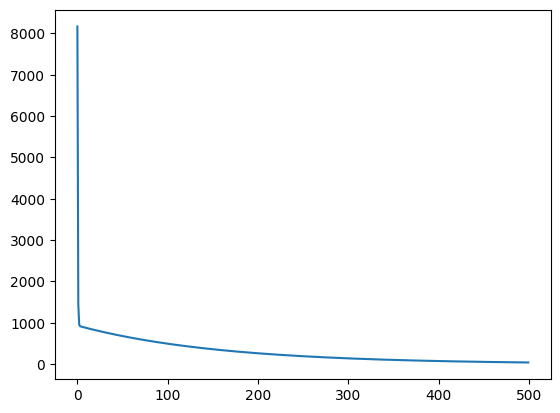

In [26]:
plt.plot(hist.history['loss'])

In [34]:
model.get_weights()   # [w1, w2], b

[array([[3.752052 ],
        [3.0632963]], dtype=float32),
 array([62.39456], dtype=float32)]

In [ ]:
#################################################################
#  로지스틱 회귀 (Sigmoid) : numpy로 학습
#  - 공부시간과 학습 예제
#################################################################
import numpy as np
import matplotlib.pyplot as plt

#공부시간 X와 성적 Y의 리스트를 만듭니다.
data = np.array([[2, 0], [4, 0], [6, 0], [8, 1], [10, 1], [12, 1], [14, 1]])
X = data[:, 0]  # shape: (7, )
Y = data[:, 1]  # shape: (7, )

# 임의의 초기값 설정
a, b = 100, 10  # 기울기, 절편
lr = 0.1        # 학습률

#시그모이드 함수를 정의합니다.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))  # shape: (7, )

# cost 함수 정의
def cost(a, b):  # 실수
    return - (Y * np.log(sigmoid(a * X + b)) +(1 - Y) * np.log(1 - sigmoid(X))).mean()

#경사 하강법을 실행합니다.
for i in range(1001):
    error = sigmoid(a * X + b) - Y  # 편차 : shape: (7, )
    a_diff = 2 * (error * X).mean()   # 실수
    b_diff = 2 * error.mean()         # 실수  
    
    a = a - lr * a_diff     # 실수
    b = b - lr * b_diff     # 실수
    if i % 100 == 0:    # 1000번 반복될 때마다 각 x_data값에 대한 현재의 a값, b값을 출력합니다.
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f  Cost=%.4f" % (i, a, b, cost(a, b)))
    
# 앞서 구한 기울기와 절편을 이용해 그래프를 그려 봅니다.
plt.scatter(X, Y)   # X: (7, ), Y:(7, )
plt.xlim(0, 15)
plt.ylim(-.1, 1.1)
x_range = (np.arange(0, 15, 0.1)) #그래프로 나타낼 x값의 범위 설정
plt.plot(x_range, sigmoid(a * x_range + b),"r")
plt.show()


In [ ]:
#################################################################
#  로지스틱 회귀 (Sigmoid) : numpy로 학습
#  - 공부시간과 학습 예제
#################################################################
import numpy as np
import matplotlib.pyplot as plt

#공부시간 X와 성적 Y의 리스트를 만듭니다.
data = np.array([[2, 0], [4, 0], [6, 0], [8, 1], [10, 1], [12, 1], [14, 1]])
X = data[:, 0]
Y = data[:, 1]

# weight와 bias의 초기값 설정
w, b = 1, 2     # 기울기, 절편
lr = 0.1       # 학습률
epoch = 5001    # 학습횟수

# 시그모이드 함수 정의
def sigmoid(w, b, X):
    return 1 / (1 + np.exp(-(w*X + b)))

# cost함수 정의  : Binary Cross Entropy
def cost(h):
    return (- (Y * np.log(h) + (1 - Y) * np.log(1 - h))).mean()

# 경사 하강법 실시
for i in range(epoch):
    error = sigmoid(w, b, X) - Y  # 각 x에서의 오차(편차)
    w_diff = (error * X).mean()     # cost를 w로 미분
    b_diff = error.mean()           # cost를 b로 미분

    # w와 b 업데이트
    w = w - lr * w_diff
    b = b - lr * b_diff
    h = sigmoid(w, b, X)
    
    if i % 200 == 0:
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f  Cost=%.4f" % (i, w, b, cost(h)))


In [ ]:
# 앞서 구한 기울기와 절편을 이용해 그래프를 그려 봅니다.
plt.scatter(X, Y)   # X: (7, ), Y:(7, )
plt.xlim(0, 15)
plt.ylim(-.1, 1.1)
x_range = (np.arange(0, 15, 0.1)) #그래프로 나타낼 x값의 범위 설정
plt.plot(x_range, sigmoid(w, b, x_range),"r")
plt.show()